In [1]:
import sys
sys.path.insert(0, '/global/common/software/lsst/common/miniconda/current/lib/python3.6/site-packages')

In [2]:
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 12

from IPython.display import display

from GCR import GCRQuery

In [4]:
import GCRCatalogs
print(GCRCatalogs.__version__)

1.10.1


In [5]:
GCRCatalogs.get_available_catalog_names()

['buzzard',
 'buzzard_high-res',
 'cosmoDC2_v1.1.4_image',
 'cosmoDC2_v1.1.4_redmagic_v0.8.1_highdens',
 'cosmoDC2_v1.1.4_redmagic_v0.8.1_highlum',
 'cosmoDC2_v1.1.4_redmapper_v0.8.1',
 'cosmoDC2_v1.1.4_small',
 'cosmoDC2_v1.1.4_wazp_v1.0_flexzboost_v1',
 'cosmoDC2_v1.1.4_wazp_v1.0_truez',
 'dc2_object_run1.2i',
 'dc2_object_run1.2i_all_columns',
 'dc2_object_run1.2i_tract4850',
 'dc2_object_run1.2i_with_photoz',
 'dc2_object_run1.2p',
 'dc2_object_run1.2p_all_columns',
 'dc2_object_run1.2p_tract4850',
 'dc2_object_run2.2i_dr2_wfd',
 'dc2_object_run2.2i_dr2_wfd_with_addons',
 'dc2_object_run2.2i_dr3a',
 'dc2_object_run2.2i_dr3a_with_metacal',
 'dc2_object_run2.2i_dr3a_with_photoz',
 'dc2_object_run2.2i_dr6',
 'dc2_object_run2.2i_dr6_v2_with_addons_v2',
 'dc2_object_run2.2i_dr6_with_addons',
 'dc2_redmagic_run2.2i_dr6_wfd_v0.8.1_highdens',
 'dc2_redmagic_run2.2i_dr6_wfd_v0.8.1_highlum',
 'dc2_redmapper_run2.2i_dr6_wfd_v0.8.1',
 'dc2_run2.2i_truth_galaxy_summary',
 'dc2_run2.2i_truth_mer

In [6]:
# List of catalogues (skysim5000_v1.1.1_small only for tests)
catalogs = ('skysim5000_v1.1.2', 'skysim5000_v1.1.1_small')
gc_all = dict(zip(catalogs, (GCRCatalogs.load_catalog(c) for c in catalogs)))
gc_all['skysim5000_v1.1.2'].list_all_quantities()

['sed_7385_458_bulge',
 'sed_3184_197_disk',
 'Mag_true_r_sdss_z0',
 'sed_8846_549_bulge',
 'sed_8329_517',
 'sed_2407_591_disk_no_host_extinction',
 'sed_4848_300_bulge_no_host_extinction',
 'sed_1552_381_disk_no_host_extinction',
 'redshift',
 'position_angle_true',
 'ellipticity_1_true_dc2',
 'sed_1933_474_bulge_no_host_extinction',
 'Mag_true_u_lsst_z0_no_host_extinction',
 'sed_6166_382_bulge_no_host_extinction',
 'ellipticity_1_bulge_true',
 'mag_r_lsst_no_host_extinction',
 'sed_1552_381',
 'sed_4848_300_no_host_extinction',
 'mag_true_y',
 'mag_z_lsst',
 'sed_6954_431_disk',
 'sed_3381_209_disk',
 'Mag_true_u_sdss_z0_no_host_extinction',
 'sed_13177_1966_bulge_no_host_extinction',
 'Mag_true_g_lsst_z0',
 'Mag_true_r_sdss_z0_no_host_extinction',
 'sed_7843_486_disk',
 'Mag_true_g_sdss_z0',
 'mag_true_u',
 'sed_1246_306_bulge_no_host_extinction',
 'sed_8329_517_bulge_no_host_extinction',
 'mag_g',
 'mag_u_lsst',
 'sed_9395_583_no_host_extinction',
 'sed_6166_382_disk',
 'mag_true

Select ongly galaxies with redshift $z<0.01$ to plot

In [7]:
data_full = gc_all['skysim5000_v1.1.2'].get_quantities(['ra', 'dec', 'redshift'], filters=['redshift < 0.01'])

In [10]:
print(len(data_full['ra']))

2249


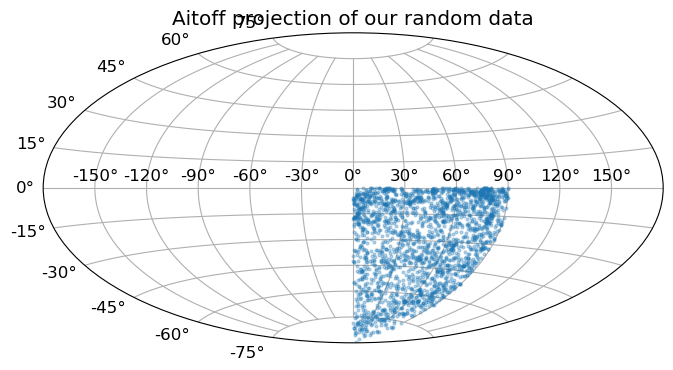

In [11]:
ra_rad = data_full['ra']*np.pi/180.
dec_rad = data_full['dec']*np.pi/180.


plt.figure(figsize=(8,4.2))
plt.subplot(111, projection="aitoff")
plt.title("Aitoff projection of our random data")
plt.grid(True)
plt.plot(ra_rad, dec_rad, 'o', markersize=2, alpha=0.3)
plt.subplots_adjust(top=0.95,bottom=0.0)
plt.show()


# Select Properties ($z<0.2$)

In [24]:
%%time
cat_skysim = GCRCatalogs.load_catalog('skysim5000_v1.1.2')
#cat1.list_all_quantities()


data_z0_2 = cat_skysim.get_quantities(['galaxy_id',
                                       'halo_id',
                                       'ra',
                                       'dec',
                                       'redshift',
                                       'mag_r_lsst',
                                       'mag_r_sdss',
                                       'stellar_mass',
                                       'halo_mass',
                                       'is_central'],
                                      filters=['redshift < 0.2'])

/global/homes/a/ataverna/.conda/envs/lsst/lib/python3.9/site-packages/GCRCatalogs/cosmodc2.py:92: RuntimeWarning: invalid value encountered in log10
  return magnitude -2.5*np.log10(magnification)


CPU times: user 4min 35s, sys: 3min 54s, total: 8min 30s
Wall time: 2h 9min 22s


# Write binary file ($z<0.2$)

In [25]:
%%time
galaxy_id = data_z0_2['galaxy_id']
halo_id = data_z0_2['halo_id']
ra = data_z0_2['ra']
dec = data_z0_2['dec']
redshift = data_z0_2['redshift']
mag_r_lsst = data_z0_2['mag_r_lsst']
mag_r_sdss = data_z0_2['mag_r_sdss']
stellar_mass = data_z0_2['stellar_mass']
halo_mass = data_z0_2['halo_mass']

is_central_int=np.int32(data_z0_2['is_central'])
is_central = is_central_int

galaxy_id = np.longlong(galaxy_id)
halo_id = np.longlong(halo_id)
ra = np.float32(ra)
dec = np.float32(dec)
redshift = np.float32(redshift)
mag_r_lsst = np.float32(mag_r_lsst)
mag_r_sdss = np.float32(mag_r_sdss)
stellar_mass = np.float32(stellar_mass)
halo_mass = np.float32(halo_mass)
is_central =is_central_int

import numpy as np
import struct
import os

count = len(galaxy_id)
fout = open('lsst_mock_z_lt_0_2.bin','wb')

fout.write(struct.pack('<I', count))

for i in range(count):
  if(i%1000)==0:
    print('iline', i, "%", i/count*100.)

  fout.write(struct.pack('<q', galaxy_id[i]))
  fout.write(struct.pack('<q', halo_id[i]))
  fout.write(struct.pack('<f', ra[i]))
  fout.write(struct.pack('<f', dec[i]))
  fout.write(struct.pack('<f', redshift[i]))
  fout.write(struct.pack('<f', mag_r_lsst[i]))
  fout.write(struct.pack('<f', mag_r_sdss[i]))
  fout.write(struct.pack('<f', halo_mass[i]))
  fout.write(struct.pack('<f', stellar_mass[i]))
  fout.write(struct.pack('<I', is_central[i]))

  count -= 1

fout.close()

assert(count == 0)

iline 0 % 0.0
iline 1000 % 0.0053833328676750405
iline 2000 % 0.010767245372009135
iline 3000 % 0.016151737606623678
iline 4000 % 0.021536809665160223
iline 5000 % 0.02692246164128049
iline 6000 % 0.03230869362866638
iline 7000 % 0.03769550572101998
iline 8000 % 0.04308289801206353
iline 9000 % 0.048470870595539506
iline 10000 % 0.053859423565210535
iline 11000 % 0.05924855701485948
iline 12000 % 0.0646382710382894
iline 13000 % 0.07002856572932353
iline 14000 % 0.07541944118180541
iline 15000 % 0.08081089748959869
iline 16000 % 0.08620293474658736
iline 17000 % 0.09159555304667553
iline 18000 % 0.09698875248378766
iline 19000 % 0.10238253315186838
iline 20000 % 0.1077768951448826
iline 21000 % 0.11317183855681548
iline 22000 % 0.11856736348167243
iline 23000 % 0.12396347001347914
iline 24000 % 0.12936015824628158
iline 25000 % 0.134757428274146
iline 26000 % 0.14015528019115886
iline 27000 % 0.14555371409142703
iline 28000 % 0.15095273006907758
iline 29000 % 0.15635232821825792
iline 

# Select Properties ($z<0.35$) [9-Julio-2025]

In [ ]:
cat_skysim = GCRCatalogs.load_catalog('skysim5000_v1.1.2')
# print(sorted(set(cat_skysim.list_all_quantities())))

In [22]:
# Obtener la lista de todas las quantities disponibles
available = set(cat_skysim.list_all_quantities())

# Tu lista de columnas deseadas
my_columns = [
    'galaxy_id', 'halo_id', 'ra', 'dec', 'redshift',
    'mag_r_lsst', 'mag_g_lsst', 'stellar_mass', 'halo_mass',
    'is_central', 'position_x', 'position_y', 'position_z',
    'mag_r_photoz', 'mag_g_photoz', 'mag_err_g_photoz', 'mag_err_r_photoz',
    'photoz_mask', 'photoz_mean', 'photoz_mode', 'photoz_odds',
    'photoz_mode_ml_red_chi2'
]

# Buscar las columnas que faltan
missing = [col for col in my_columns if col not in available]

# Mostrar resultados
print("Columnas que FALTAN en el catálogo:")
for col in missing:
    print(" -", col)

#print("\nColumnas disponibles:\n", sorted(available))

Columnas que FALTAN en el catálogo:
 - mag_r_photoz
 - mag_g_photoz
 - mag_err_g_photoz
 - mag_err_r_photoz
 - photoz_mask
 - photoz_mean
 - photoz_mode
 - photoz_odds
 - photoz_mode_ml_red_chi2


In [23]:
%%time

cols_pedro_cosmoDC2 = ['galaxy_id','halo_id','ra','dec','redshift', 'mag_r_lsst','mag_g_lsst','stellar_mass','halo_mass','is_central',
                       'position_x','position_y','position_z']

#'mag_r_photoz','mag_g_photoz','mag_err_g_photoz','mag_err_r_photoz','photoz_mean','photoz_mode','photoz_odds','photoz_mask','photoz_mode_ml_red_chi2'

data_z0_35 = cat_skysim.get_quantities(cols_pedro_cosmoDC2, filters=['redshift < 0.35'])

/global/homes/a/ataverna/.conda/envs/lsst/lib/python3.9/site-packages/GCRCatalogs/cosmodc2.py:92: RuntimeWarning: invalid value encountered in log10
  return magnitude -2.5*np.log10(magnification)


CPU times: user 4min 43s, sys: 9min 43s, total: 14min 27s
Wall time: 1h 55min 9s


# Write binary file ($z<0.35$)

In [28]:
idgal     = np.longlong(data_z0_35['galaxy_id'])
halo_id       = np.longlong(data_z0_35['halo_id'])
ra            = np.float32(data_z0_35['ra'])
dec           = np.float32(data_z0_35['dec'])
z      = np.float32(data_z0_35['redshift'])
mr_lsst    = np.float32(data_z0_35['mag_r_lsst'])
mg_lsst    = np.float32(data_z0_35['mag_g_lsst'])
#mag_r_sdss    = np.float32(data_z0_35['mag_r_sdss'])
lstellar_mass  = np.float32(data_z0_35['stellar_mass'])
lhalo_mass     = np.float32(data_z0_35['halo_mass'])
is_central_int=np.int32(data_z0_35['is_central'])
is_central    = is_central_int
position_x    = np.float32(data_z0_35['position_x'])
position_y    = np.float32(data_z0_35['position_y'])
position_z    = np.float32(data_z0_35['position_z'])

# cut apparent magnitude
ii = np.where(mr_lsst<=21.)
print(len(mr_lsst[ii]))


tofile = [idgal[ii], ra[ii], dec[ii], z[ii], mr_lsst[ii], mg_lsst[ii],
          halo_id[ii], lhalo_mass[ii], lstellar_mass[ii],
          position_x[ii], position_y[ii], position_z[ii], is_central[ii]]
print(np.shape(tofile))

outfil = 'mock_SkySim_z_lt_0_35_mag_lt_21.dat'
with open(outfil, 'w') as outf:
    outf.write('#galid, ra, dec, z, mr_lsst, mg_lsst, halo_id, loghalo_mass, logstellar_mass, position_x, position_y, position_z, is_central \n')
    #np.savetxt(outf,np.column_stack(tofile), delimiter="  ")
    np.savetxt(outf,np.column_stack(tofile),
               fmt=('%.14d %.5f %.5f %.5f %.5f %.5f %.14d %.5f %.5f %.5f %.5f %.5f %.5d'), delimiter="  ")
outf.closed
print('Output: {}'.format(outfil))

9134213
(13, 9134213)
Output: mock_SkySim_z_lt_0_35_mag_lt_21.dat


In [26]:
%%time
galaxy_id     = np.longlong(data_z0_35['galaxy_id'])
halo_id       = np.longlong(data_z0_35['halo_id'])
ra            = np.float32(data_z0_35['ra'])
dec           = np.float32(data_z0_35['dec'])
redshift      = np.float32(data_z0_35['redshift'])
mag_r_lsst    = np.float32(data_z0_35['mag_r_lsst'])
mag_g_lsst    = np.float32(data_z0_35['mag_g_lsst'])
#mag_r_sdss    = np.float32(data_z0_35['mag_r_sdss'])
stellar_mass  = np.float32(data_z0_35['stellar_mass'])
halo_mass     = np.float32(data_z0_35['halo_mass'])

is_central_int=np.int32(data_z0_35['is_central'])
is_central    = is_central_int

position_x    = np.float32(data_z0_35['position_x'])
position_y    = np.float32(data_z0_35['position_y'])
position_z    = np.float32(data_z0_35['position_z'])
#mag_r_photoz  = np.float32(data_z0_35['mag_r_photoz'])
#mag_g_photoz  = np.float32(data_z0_35['mag_g_photoz'])
#mag_err_g     = np.float32(data_z0_35['mag_err_g_photoz'])
#mag_err_r     = np.float32(data_z0_35['mag_err_r_photoz'])
#photoz_mask   = np.int32(data_z0_35['photoz_mask'])
#photoz_mean   = np.float32(data_z0_35['photoz_mean'])
#photoz_mode   = np.float32(data_z0_35['photoz_mode'])
#photoz_odds   = np.float32(data_z0_35['photoz_odds'])
#photoz_chi2   = np.float32(data_z0_35['photoz_mode_ml_red_chi2'])



import numpy as np
import struct
import os

count = len(galaxy_id)
fout = open('lsst_mock_z_lt_0_35.bin','wb')

fout.write(struct.pack('<I', count))

for i in range(count):
  if(i%10_000)==0:
    print('iline', i, "%", i/count*100.)

  fout.write(struct.pack('<q', galaxy_id[i]))
  fout.write(struct.pack('<q', halo_id[i]))
  fout.write(struct.pack('<f', ra[i]))
  fout.write(struct.pack('<f', dec[i]))
  fout.write(struct.pack('<f', redshift[i]))
  fout.write(struct.pack('<f', mag_r_lsst[i]))
  fout.write(struct.pack('<f', mag_g_lsst[i]))    
  #fout.write(struct.pack('<f', mag_r_sdss[i]))
  fout.write(struct.pack('<f', halo_mass[i]))
  fout.write(struct.pack('<f', stellar_mass[i]))
  fout.write(struct.pack('<I', is_central[i]))

  fout.write(struct.pack('<f', position_x[i]))
  fout.write(struct.pack('<f', position_y[i]))
  fout.write(struct.pack('<f', position_z[i]))

  #fout.write(struct.pack('<f', photoz_mean[i]))
  #fout.write(struct.pack('<f', photoz_mode[i]))
  #fout.write(struct.pack('<f', photoz_odds[i]))

  #fout.write(struct.pack('<f', mag_err_g[i]))
  #fout.write(struct.pack('<f', mag_err_r[i]))
  #fout.write(struct.pack('<f', mag_r_photoz[i]))
  #fout.write(struct.pack('<f', mag_g_photoz[i]))

  count -= 1

fout.close()

assert(count == 0)

iline 0 % 0.0
iline 10000 % 0.011012671896107334
iline 20000 % 0.022027769638210955
iline 30000 % 0.03304529402793881
iline 40000 % 0.04406524586727207
iline 50000 % 0.05508762595854534
iline 60000 % 0.0661124351044469
iline 70000 % 0.0771396741080188
iline 80000 % 0.08816934377265712
iline 90000 % 0.09920144490211215
iline 100000 % 0.11023597830048862
iline 110000 % 0.12127294477224583
iline 120000 % 0.1323123451221979
iline 130000 % 0.14335418015551393
iline 140000 % 0.1543984506777182
iline 150000 % 0.16544515749469044
iline 160000 % 0.1764943014126659
iline 170000 % 0.18754588323823562
iline 180000 % 0.1985999037783466
iline 190000 % 0.20965636384030212
iline 200000 % 0.22071526423176163
iline 210000 % 0.2317766057607413
iline 220000 % 0.24284038923561407
iline 230000 % 0.25390661546510973
iline 240000 % 0.2649752852583153
iline 250000 % 0.2760463994246751
iline 260000 % 0.28711995877399116
iline 270000 % 0.298195964116423
iline 280000 % 0.30927441626248825
iline 290000 % 0.3203553

In [27]:
redshift

array([0.01875939, 0.02340041, 0.02429551, ..., 0.34340793, 0.34588438,
       0.33807752], dtype=float32)

# Prueba ejemplo github

In [7]:
class ConditionalLuminosityFunction(object):
    
    def __init__(self, band='r', magnitude_bins=None, mass_bins=None, z_bins=None, **kwargs):
        
        possible_Mag_fields = ('Mag_true_{}_lsst_z0', 
                               'Mag_true_{}_lsst_z01', 
                               'Mag_true_{}_des_z0', 
                               'Mag_true_{}_des_z01',
                               'Mag_true_{}_sdss_z0',
                               'Mag_true_{}_sdss_z01',
                              )
        
        self.possible_Mag_fields = [f.format(band) for f in possible_Mag_fields]
        self.band = band
        
        self.magnitude_bins   = magnitude_bins or np.linspace(-25, -18, 29)
        self.mass_bins        = mass_bins or np.logspace(12, 15, 5)
        self.z_bins           = z_bins or np.linspace(0, 0.5, 3)
        
        self.n_magnitude_bins = len(self.magnitude_bins) - 1
        self.n_mass_bins      = len(self.mass_bins) - 1
        self.n_z_bins         = len(self.z_bins) - 1

        self.dmag = self.magnitude_bins[1:] - self.magnitude_bins[:-1]
        self.mag_center = (self.magnitude_bins[1:] + self.magnitude_bins[:-1])*0.5
        
        self._other_kwargs = kwargs
        
        
    def prepare_galaxy_catalog(self, gc):
        
        quantities_needed = {'redshift_true', 'is_central', 'halo_mass'}

        if gc.has_quantities(['truth/RHALO', 'truth/R200']):
            gc.add_quantity_modifier('r_host', 'truth/RHALO', overwrite=True)
            gc.add_quantity_modifier('r_vir', 'truth/R200', overwrite=True)
            quantities_needed.add('r_host')
            quantities_needed.add('r_vir')

        try:
            absolute_magnitude_field = gc.first_available(*self.possible_Mag_fields)
        except ValueError:
            return

        quantities_needed.add(absolute_magnitude_field)
        if not gc.has_quantities(quantities_needed):
            return

        return absolute_magnitude_field, quantities_needed
        
        
    def run_validation_test(self, galaxy_catalog, catalog_name, base_output_dir=None):
        
        prepared = self.prepare_galaxy_catalog(galaxy_catalog)
        if prepared is None:
            TestResult(skipped=True)

        absolute_magnitude_field, quantities_needed = prepared
        colnames = [absolute_magnitude_field, 'halo_mass', 'redshift_true']
        bins = (self.magnitude_bins, self.mass_bins, self.z_bins)
        hist_cen = np.zeros((self.n_magnitude_bins, self.n_mass_bins, self.n_z_bins))
        hist_sat = np.zeros_like(hist_cen)

        cen_query = GCRQuery('is_central')
        sat_query = ~cen_query
        if 'r_host' in quantities_needed and 'r_vir' in quantities_needed:
            sat_query &= GCRQuery('r_host < r_vir')

        for data in galaxy_catalog.get_quantities(quantities_needed, return_iterator=True):
            cen_mask = cen_query.mask(data)
            sat_mask = sat_query.mask(data)
            data = np.stack((data[k] for k in colnames)).T
            hist_cen += np.histogramdd(data[cen_mask], bins)[0]
            hist_sat += np.histogramdd(data[sat_mask], bins)[0]

        del data, cen_mask, sat_mask

        halo_counts = hist_cen.sum(axis=0)
        clf = dict()
        clf['sat'] = hist_sat / halo_counts
        clf['cen'] = hist_cen / halo_counts
        clf['tot'] = clf['sat'] + clf['cen']

        return clf
        
        
    def make_plot(self, clf, name):
        fig, ax = plt.subplots(self.n_mass_bins, self.n_z_bins, sharex=True, sharey=True, figsize=(12,10), dpi=100)

        for i in range(self.n_z_bins):
            for j in range(self.n_mass_bins):
                ax_this = ax[j,i]
                for k, ls in zip(('total', 'satellites', 'centrals'), ('-', ':', '--')):
                    ax_this.semilogy(self.mag_center, clf[k[:3]][:,j,i]/self.dmag, label=k, ls=ls)
                ax_this.set_ylim(0.05, 50)
                bins = self.mass_bins[j], self.mass_bins[j+1], self.z_bins[i], self.z_bins[i+1]
                ax_this.text(-25, 10, '${:.1E}\\leq M <{:.1E}$\n${:g}\\leq z<{:g}$'.format(*bins))

        ax_this.legend(loc='lower right', frameon=False, fontsize='medium')

        ax = fig.add_subplot(111, frameon=False)
        ax.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')
        ax.grid(False)
        ax.set_ylabel(r'$\phi(M_{{{}}}\,|\,M_{{\rm vir}},z)\quad[{{\rm Mag}}^{{-1}}]$'.format(self.band))
        ax.set_xlabel(r'$M_{{{}}}\quad[{{\rm Mag}}]$'.format(self.band))
        ax.set_title(name)

        fig.tight_layout()
        display(fig)
        plt.close(fig)

In [8]:
clf_test = ConditionalLuminosityFunction()

#### Prueba con catalogo `gc_all`

In [9]:
clf_all = dict()
for label, gc_this in gc_all.items():
    clf_all[label] = clf_test.run_validation_test(gc_this, label)

/global/homes/a/ataverna/.conda/envs/lsst/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3433: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  exec(code_obj, self.user_global_ns, self.user_ns)
/tmp/ipykernel_65418/1008424655.py:80: RuntimeWarning: divide by zero encountered in divide
  clf['sat'] = hist_sat / halo_counts
/tmp/ipykernel_65418/1008424655.py:80: RuntimeWarning: invalid value encountered in divide
  clf['sat'] = hist_sat / halo_counts
/tmp/ipykernel_65418/1008424655.py:81: RuntimeWarning: invalid value encountered in divide
  clf['cen'] = hist_cen / halo_counts


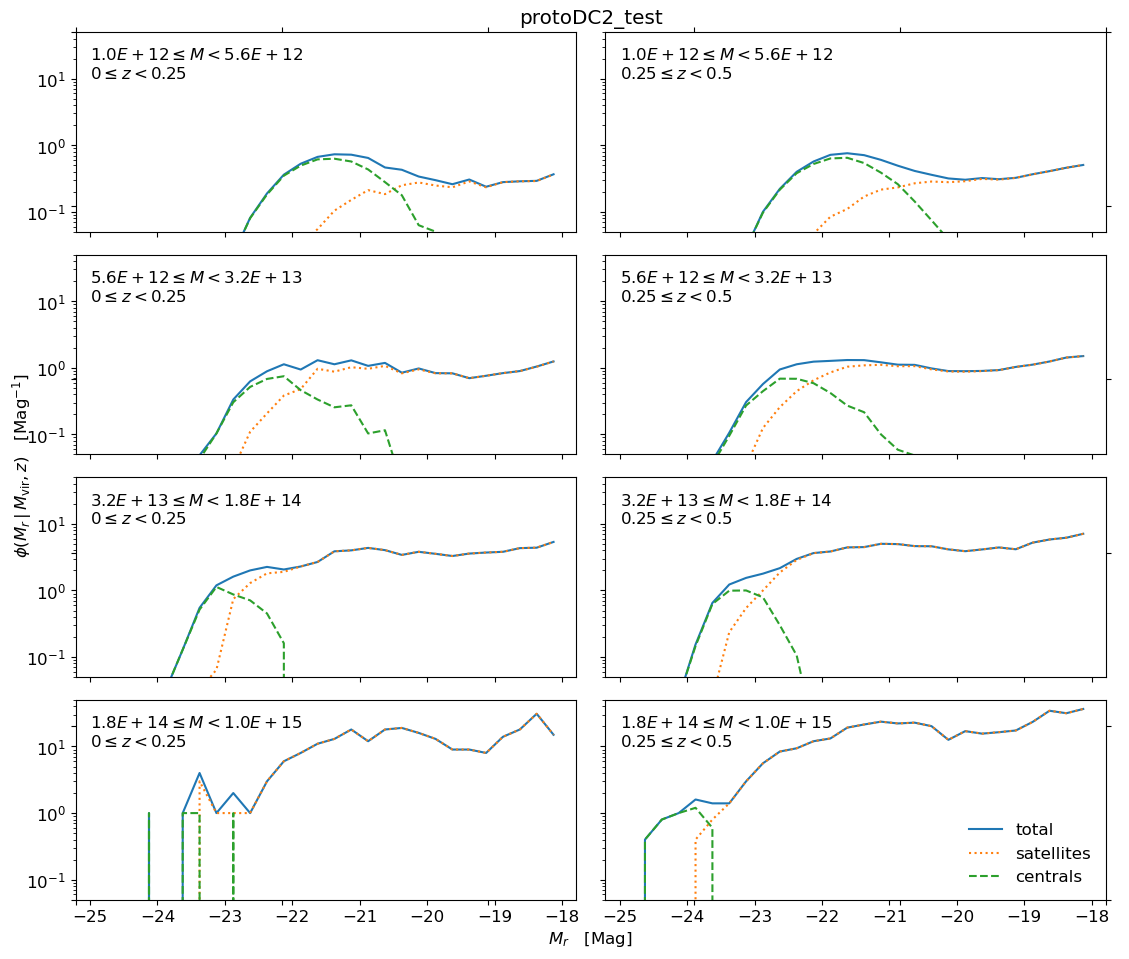

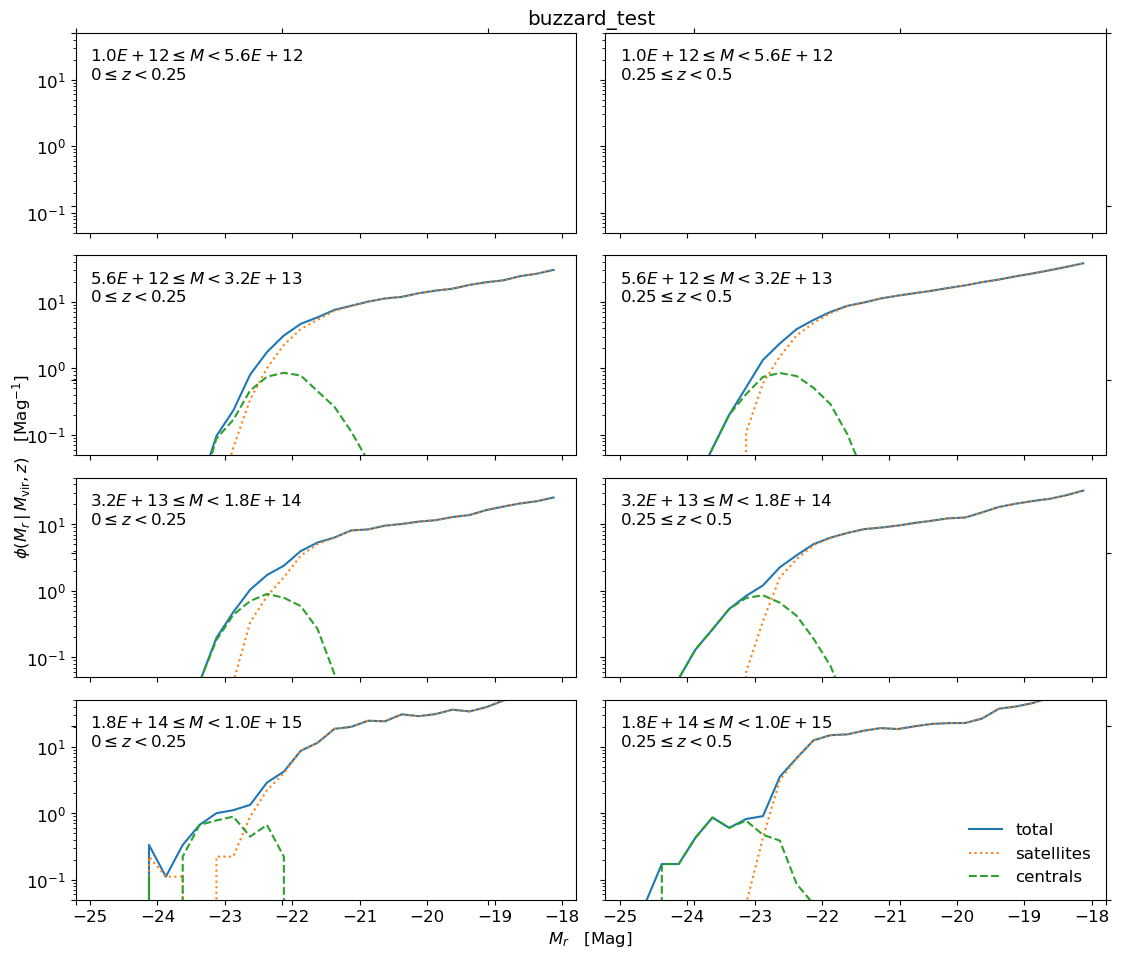

In [10]:
for label, clf_this in clf_all.items():
    clf_test.make_plot(clf_this, label)